# dem4cli v2 demo

## Description 

Updates compared to original version of Wim/Luke
- **life expectancy data** 
    - updated from UNWPP2019 to UNWPP2024
    - Input data: years left to live at age 5 (e(x) for x=5). As in original version, this is converted to life expectancy at birth, neglecting child mortality, and adding 6 extra years to life expectancy to go from cohort to period life expectancy. 
    - Previously was extrapolated for later birth years (from 2013 to 2020) by holding the life expectancy constant and was interpolated for exact years because data was provided at 5-year snapshots. Now does not need to be extrapolated for later birth years because this data is now available 1950-2023 (estimates) but also 2024-2100 (projections, medium variant), and does not need to be interpolated because provided for exact years. 
    - You can therefore have this data for all birth years 1945-2095. In the standard settings life expectancy is provided for birth years 1950-2025 
    - Previously only available starting from birth year 1960? Not sure why because original UNWPP2019 data also has data 1950-1955. 
- **cohort size data** 
    - Updated from WCDE v2 (SSPs of CMIP6) to 2 options: can now come from WCDE (SSP v3.2-beta, i.e. CMIP7 projections), as snapshots every 5 years for 5-year age groups, or from UNWPP2024, for exact years/ages. In both cases estimates and projections are both provided, for the period 1950-2100. 
    - WCDE data needs interpolation of ages/years, which I corrected to be mean-preserving. UNWPP2024 does not need interpolation. 
    - UNWPP2024 seems similar to WCDE v3.2 SSP2 (middle of the road / median demographic scenario)
    - *to test*: integrate in wrapper function, see how many countries now available
- **country masks**
    - added option to get it from fractional country masks ISIpedia, so you don't lose small countries and coastal population. 
    - *to do*: make it an option whether to choose shapefiles or fractional country masks, for having also sub-national analysis
- **spatial resolution**
    - available now at 0.5 and 0.1 degrees (depends on population data and gridded / fractional country masks, if using )
- **gridded population data**
    - updated from ISIMIP2 data to COMPASS data (gridded and harmonized at national level with SSPs v3.2-beta), from Dominik
    - available at 0.5 and 0.1 resolution as count of number of people
    - *note*: in dem4cli v1 there is option to use ISIMIP3 population data 
- **available countries**
    - when using cohorts from SSP v3.2 and fractional country masks, 185 countries available instead of 177, based on data availability and WB region categorization. 
    - if you use cohorts from UNWPP instead, you get 192 available countries 
    - if you use cohorts from UNWPP and shapefiles you get 183 countries available

## Functions

**Part 1. Demographics preprocesing**

- **load_cohort_sizes()** loads cohort sizes reconstructions and projections
    - v2 option 1: WCDE v3.2-beta (flags['cohort_sizes_source'] ='WCDE') from SSPs, estimates until 2025, projections thereafter, for 5-year snapshots and 5-year age groups (no uncertainties, can pick SSP). 
    - v2 option 2: UNWPP2024 (flags['cohort_sizes_source'] = 'UNWPP2024'), estimates until 2023, projections thereafter (with uncertainties), for exact ages/years >*finish testing*
- **interpolate_cohortsize_countries()** interpolates from 5-year age brackets to exact ages, only necessary for WCDE
- **load_population()** loads gridded pop data
    - dem4cli v2: from COMPASS (pre-CMIP7 version, harmonized with SSP v3.2-beta at national level)
- **load_unwpp_lifeexpectancy()** loads and cleans life expectancy data e(x) at age 5 from UNWPP2024
    - UNWPP2024 provides estimates 1950-2023 and projections 2024-2100, for exact ages/years
- **get_life_expectancies()** goes from raw e(x) data period -> cohort life expectancy at age 0 neglecting child mortality
- **load_countrymasks_fillcoasts()** loads fractional countrymasks, with options for filling coastal pixels to sum to 1 
    - TODO: see whether to do this or stick to shapefiles
- wrapper function that runs everything: **preprocess_all_country_data()**
    - option to give a bounding box 

## To do:
- wrapper function option to cut years in other data not just pop data??? 
- test wrapper fxn with cohorts from UNWPP2024, see how many countries are kept, include it here in the demo!
- make country mask shapefile/gridded an option and if gridded integrate in Lexp functions - or just keep shapefiles - decide! or keep option!


**Part 2. Lifetime exposure**
- GMT mapping 
- lifetime exposure functions








In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
from math import ceil 
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

sys.path.append('..')
from population_demographics_v2 import * 

In [2]:
flags

# TODO: make more OOP and make init function where users can define this

{'version': 2,
 'pop_resolution': 0.5,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

In [3]:
bbox_europe = [ 31.99,  71.09, -14.96,  34.94]

## Part 1. Demographics preprocessing

### a) individual functions

In [4]:
df_metadata = load_country_metadata(
    filepath_world_bank = os.path.join(script_dir, 'data/income-groups/world_bank/CLASS.xlsx'), # what year is this from? 
)

# load metadata from world bank

In [5]:
df_unwpp = load_unwpp_lifeexpectancy(filepath_lifeexpectancy = filepath_lifeexpectancy) 
df_life_expectancy_5 = get_life_expectancies(df_unwpp,
                                            start_birthyear=1950,
                                            end_birthyear=2025) 

# load life expectancy data and clean 
# go from 'period' to 'cohort' life expectancy


In [6]:
endyear = ceil(max(df_life_expectancy_5.values.flatten()) + 2025)
endyear

#endyear=2119 


2119

In [7]:
df_cohort_sizes_wcde, ages, years = load_cohort_sizes(dir_cohortsizes =  os.path.join(data_dir, 'cohort-sizes/WCDE_v3.2.beta'), 
                                                    ssp=2, 
                                                    data_source = 'WCDE',
                                                    by_sex=False)

# loads raw cohort size data from historical + ssp and cleans to keep only relevant information
# option 1: from WCDE

loading cohort sizes from WCDE


In [8]:
da_cohort_size_wcde = interpolate_cohortsize_countries(
                        df_cohort_sizes_wcde,
                        ages,
                        years,
                        data_source = 'WCDE',
                        extend_method = 'linear', 
                        startyear= 1950,
                        endyear = endyear, # have to still implement for UNWPP ! 
                    )

# interpolates cohort sizes from 5 year to single year and corrects to preserve mean - only necessary for WCDE data 
# SSP names 


interpolating cohort sizes per country


In [9]:
da_cohort_size_wcde_extrap = interpolate_cohortsize_countries(
                        df_cohort_sizes_wcde,
                        ages,
                        years,
                        data_source = 'WCDE',
                        extend_method = 'slinear', 
                        startyear= 1950,
                        endyear = endyear, # have to still implement for UNWPP ! 
                    )

# interpolates cohort sizes from 5 year to single year and corrects to preserve mean - only necessary for WCDE data 
# SSP names 

interpolating cohort sizes per country
after interpolation and mean-preserving correction there are some neg numbers in 6, Anguilla, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 44, Comoros, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 74, Gabon, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 127, Mali, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 128, Malta, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 173, Rwanda, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 183, San Marino, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 198, South Sudan, setting them to zero
after interpolation and mean-preservi

In [10]:
ages

array([  2,   7,  12,  17,  22,  27,  32,  37,  42,  47,  52,  57,  62,
        67,  72,  77,  82,  87,  92,  97, 102])

In [11]:
years

# WCDE data available at 5-year snapshots and 5- year age groups

array([1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000,
       2005, 2010, 2015, 2020, 2025, 2030, 2035, 2040, 2045, 2050, 2055,
       2060, 2065, 2070, 2075, 2080, 2085, 2090, 2095, 2100])

In [12]:
df_cohort_sizes_unwpp, ages, years = load_cohort_sizes(dir_cohortsizes =  dir_cohortsizes, 
                                                    ssp=None, 
                                                    data_source = 'UNWPP2024',
                                                    by_sex=False)

# Option 2. open unwpp cohort size data estimates and projections 

#TODO: rename from 'df' to something else because its not a df anymore (da)

                                                  

loading cohort sizes from UNWPP2024


In [13]:

da_cohort_size_unwpp = interpolate_cohortsize_countries(
                        df_cohort_sizes_unwpp,
                        ages,
                        years,
                        data_source = 'UNWPP2024',
                        extend_method = 'linear', # extends with constant
                        startyear= 1950,
                        endyear = endyear, 
                    )

In [14]:
ages

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100])

In [15]:
years

# UNWPP data available at exact ages/years

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026,
       2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037,
       2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048,
       2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058, 2059,
       2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2068, 2069, 2070,
       2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080, 2081,
       2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091, 2092,
       2093, 2094, 2095, 2096, 2097, 2098, 2099, 21

In [16]:

da_population = load_population(
    dir_population= dir_population, 
    startyear=1950,
    endyear=endyear,
    ssp=2,
    urbanrural=False,
    bbox = None # optional : latmin, latmax, lonmin, lonmax

)

# load gridded population data, crop over Europe (optional cropping)


opening compass - historical
opening compass - ssp2


In [17]:


gdf_country_borders, countries_regions, countries_mask, df_countries = load_countrymask(
                                                                        filepath_countrymask=filepath_countrymask,
                                                                        data_source_countrymask=flags['countrymask'],
                                                                        df_metadata=df_metadata,       
                                                                        da_population=da_population,
                                                                        fillcoast=False, # True if you want to preprocess and fill coastal pixels to not lose coastal pops (done already in preprocessed files)
                                                                        fix_smallislands=False, # done in preprocessed input files for 0.5, not for 0.1 - TODO: check if necessary at 0.1 or not ! 
                                                                        bbox=None,
                                                                        )


# open country masks: note, only testing Lexp with shapefiles as Luke's original

# TODO: make hi res to show difference here in demo


In [18]:


df_metadata_filtered = filter_countries_all_datasets(df_metadata,
                                                    filepath_lookuptable=filepath_lookuptable,
                                                    countrymask = gdf_country_borders,
                                                    worldbank_filter=True, 
                                                    data_source_cohortsizes='UNWPP2024')

### b) wrapper function (Global)

In [4]:
# wrapper function that runs everything for S2S / lifetime exposure calcs

d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    ssp=2,
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = None,

    filepath_countrymask = filepath_countrymask,    # country masks 
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )


# TODO: see if Amaury needs other objects I didn't include in d_countries 
# 'birth_years' and 'mask' I am not sure... 

# NOTE! overlap between mask, UNWPP and SSP projections is 218 countries 
# of these only 198 countries have full cohort size projections into future with WCDE SSPs, of these 185 also categorized in WB
# if using WPP cohort size projections, 192 countries are available
# if using shapefile, 183 countries are resolved 

# TODO: check what extra countries are in old (177) vs. new in S2S




load_country_metadata took 0.06 s
load_unwpp_lifeexpectancy took 23.60 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 25.72 s
interpolate_cohortsize_countries took 0.03 s
opening compass - historical
opening compass - ssp2
load_population took 4.08 s
load_countrymask took 38.09 s
filter_countries_all_datasets took 0.01 s
preprocess_all_country_data took 91.64 s


### Check data

#### a) from raw functions

In [31]:
df_metadata # = intersection of ISIMIP mask and World Bank official country list

,country,abbreviation,country_code,region,incomegroup
0,Afghanistan,AFG,3,South Asia,Low income
1,Albania,ALB,103,Europe & Central Asia,Upper middle income
2,Algeria,DZA,203,Middle East & North Africa,Upper middle income
3,Andorra,AND,403,Europe & Central Asia,High income
4,Angola,AGO,503,Sub-Saharan Africa,Lower middle income
...,...,...,...,...,...
190,Venezuela (Bolivarian Republic of),VEN,22503,Latin America & Caribbean,NaN
191,Viet Nam,VNM,22603,East Asia & Pacific,Lower middle income
192,Yemen,YEM,23003,Middle East & North Africa,Low income
193,Zambia,ZMB,23103,Sub-Saharan Africa,Lower middle income


##### compare the different cohort sizes WCDE vs. UNWPP

Until 2050 they seem similar also at national level. Total population at EOC is slightly higher in UNWPP, and the population is accordingly older in SSP2. 

In [32]:
da_cohort_size_wcde

<xarray.DataArray 'cohort_size' (country: 236, time: 170, ages: 105)>
array([[[2.57221194e+02, 2.57221194e+02, 2.57221194e+02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.57859125e+02, 2.57859125e+02, 2.57859125e+02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.58497056e+02, 2.58497056e+02, 2.58497056e+02, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [1.19048485e+03, 1.19048485e+03, 1.19048485e+03, ...,
         2.29805787e-01, 2.29805787e-01, 2.29805787e-01],
        [1.19048485e+03, 1.19048485e+03, 1.19048485e+03, ...,
         2.29805787e-01, 2.29805787e-01, 2.29805787e-01],
        [1.19048485e+03, 1.19048485e+03, 1.19048485e+03, ...,
         2.29805787e-01, 2.29805787e-01, 2.29805787e-01]],

       [[3.74757019e+01, 3.74757019e+01, 3.74757019e+01, ...,
         1.59600998e-03, 1.59600998e-03, 1.59600998e-03],
        [3.94971530e+01, 3.94971530e+01, 3.94971530e+01, ...,
         1.75556152e-03, 1.75556152e-03, 1.75556152e-03],
        [4.15186042e+01, 4.15186042e+01, 4.15186042e+01, ...,
         1.91511307e-03, 1.91511307e-03, 1.91511307e-03],
...
        [5.15212069e+02, 5.15212069e+02, 5.15212069e+02, ...,
         2.01314708e-01, 2.01314708e-01, 2.01314708e-01],
        [5.15212069e+02, 5.15212069e+02, 5.15212069e+02, ...,
         2.01314708e-01, 2.01314708e-01, 2.01314708e-01],
        [5.15212069e+02, 5.15212069e+02, 5.15212069e+02, ...,
         2.01314708e-01, 2.01314708e-01, 2.01314708e-01]],

       [[9.75242255e+01, 9.75242255e+01, 9.75242255e+01, ...,
         3.27868852e-04, 3.27868852e-04, 3.27868852e-04],
        [1.04618655e+02, 1.04618655e+02, 1.04618655e+02, ...,
         2.99332119e-04, 2.99332119e-04, 2.99332119e-04],
        [1.11713085e+02, 1.11713085e+02, 1.11713085e+02, ...,
         2.70795386e-04, 2.70795386e-04, 2.70795386e-04],
        ...,
        [2.53000540e+02, 2.53000540e+02, 2.53000540e+02, ...,
         4.27198431e-01, 4.27198431e-01, 4.27198431e-01],
        [2.53000540e+02, 2.53000540e+02, 2.53000540e+02, ...,
         4.27198431e-01, 4.27198431e-01, 4.27198431e-01],
        [2.53000540e+02, 2.53000540e+02, 2.53000540e+02, ...,
         4.27198431e-01, 4.27198431e-01, 4.27198431e-01]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103 104

In [33]:
da_cohort_size_unwpp # this stops at 100 y.o. bc otherwise you change total pop size 

<xarray.DataArray 'cohort_size' (country: 237, time: 170, ages: 101)>
array([[[3.1581850e+02, 2.6917450e+02, 2.5050700e+02, ...,
         1.5000000e-03, 5.0000000e-04, 0.0000000e+00],
        [3.1596150e+02, 2.6723850e+02, 2.5043500e+02, ...,
         1.0000000e-03, 5.0000000e-04, 0.0000000e+00],
        [3.2254100e+02, 2.6814350e+02, 2.4889100e+02, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        ...,
        [1.8011550e+03, 1.8048325e+03, 1.8074890e+03, ...,
         7.1515000e+00, 4.4495000e+00, 6.1445000e+00],
        [1.8011550e+03, 1.8048325e+03, 1.8074890e+03, ...,
         7.1515000e+00, 4.4495000e+00, 6.1445000e+00],
        [1.8011550e+03, 1.8048325e+03, 1.8074890e+03, ...,
         7.1515000e+00, 4.4495000e+00, 6.1445000e+00]],

       [[4.4996000e+01, 3.9432000e+01, 3.5923000e+01, ...,
         1.6000000e-02, 1.0500000e-02, 1.3500000e-02],
        [4.7037000e+01, 4.0547500e+01, 3.7188500e+01, ...,
         1.4000000e-02, 9.0000000e-03, 1.1500000e-02],
        [4.9370500e+01, 4.2429500e+01, 3.8437000e+01, ...,
         1.2500000e-02, 8.0000000e-03, 1.2000000e-02],
...
        [9.1798000e+02, 9.1783250e+02, 9.1942400e+02, ...,
         5.3015000e+00, 3.4925000e+00, 5.7090000e+00],
        [9.1798000e+02, 9.1783250e+02, 9.1942400e+02, ...,
         5.3015000e+00, 3.4925000e+00, 5.7090000e+00],
        [9.1798000e+02, 9.1783250e+02, 9.1942400e+02, ...,
         5.3015000e+00, 3.4925000e+00, 5.7090000e+00]],

       [[1.2761300e+02, 1.0412350e+02, 8.7942000e+01, ...,
         7.5000000e-03, 4.5000000e-03, 5.0000000e-03],
        [1.3197050e+02, 1.2077800e+02, 1.0069000e+02, ...,
         7.5000000e-03, 5.0000000e-03, 6.0000000e-03],
        [1.3534650e+02, 1.2503900e+02, 1.1691000e+02, ...,
         5.5000000e-03, 5.5000000e-03, 5.5000000e-03],
        ...,
        [4.9595450e+02, 4.9633050e+02, 4.9703450e+02, ...,
         5.0470000e+00, 3.3800000e+00, 5.4865000e+00],
        [4.9595450e+02, 4.9633050e+02, 4.9703450e+02, ...,
         5.0470000e+00, 3.3800000e+00, 5.4865000e+00],
        [4.9595450e+02, 4.9633050e+02, 4.9703450e+02, ...,
         5.0470000e+00, 3.3800000e+00, 5.4865000e+00]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 9 ... 91 92 93 94 95 96 97 98 99 100

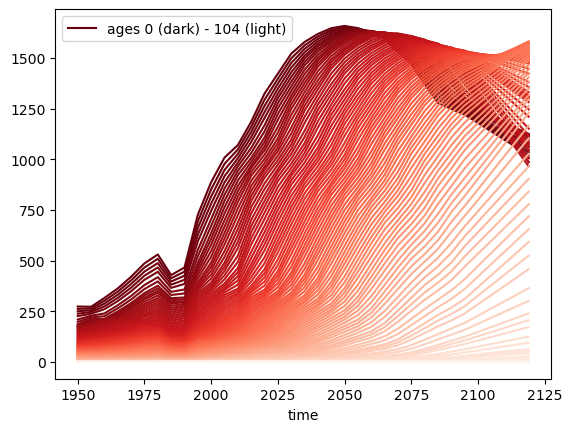

In [ ]:
da_cohort_size_wcde_extrap.sel(country='Afghanistan').to_pandas().plot( cmap='Reds_r') 
# slinear extrapolates with spline linear to get ages 0-2, 102-104 and years after 2100

plt.legend(['ages 0 (dark) - 104 (light)'])

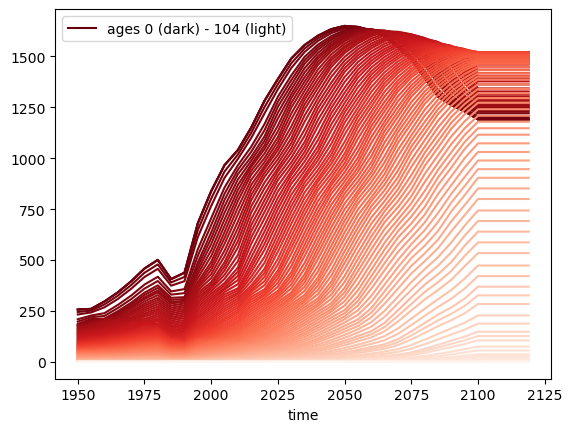

In [35]:
da_cohort_size_wcde.sel(country='Afghanistan').to_pandas().plot(cmap='Reds_r') # linear ages 0-1 are the same as age 2, ages above 102 are constant, years after 2100 are constant

plt.legend(['ages 0 (dark) - 104 (light)'])

# more aging in ssp2 than unwpp

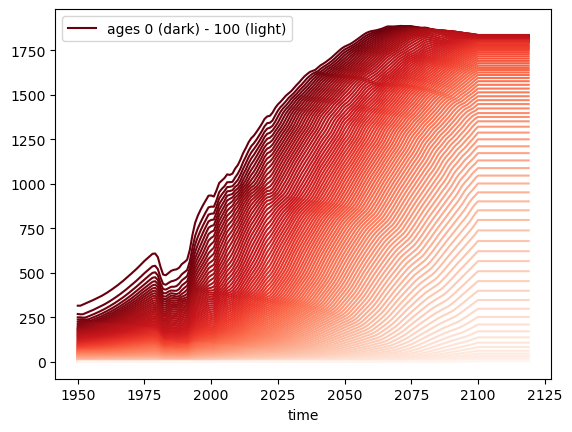

In [36]:
da_cohort_size_unwpp.sel(country='Afghanistan').to_pandas().plot( cmap='Reds_r') # linear years after 100 are constant, and ages above 100 are constant, but ages 0-2 are different bc provided by data 

plt.legend(['ages 0 (dark) - 100 (light)'])

Text(0, 0.5, 'global population (billions)')

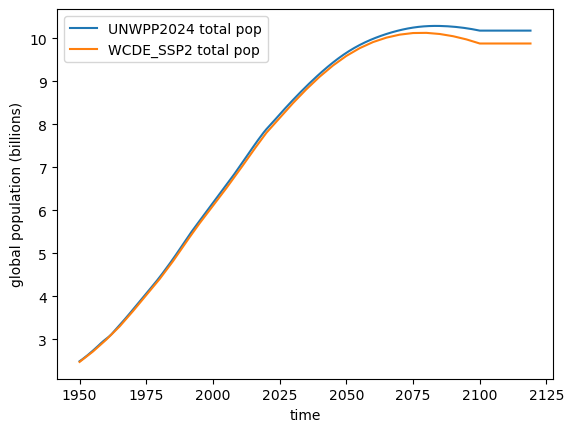

In [37]:
fig,ax = plt.subplots()

# original units = thousands dive by 1e6 -> millions -> billions

(da_cohort_size_unwpp.sum(dim=['country', 'ages']) / 1e6 ).astype(float).plot(ax=ax, label='UNWPP2024 total pop')
(da_cohort_size_wcde.sum(dim=['country', 'ages']) / 1e6).plot(ax=ax, label='WCDE_SSP2 total pop')

plt.legend()

plt.ylabel('global population (billions)')

# UNWPP2024 has a slightly higher population

Text(0, 0.5, 'global cohort size (billions)')

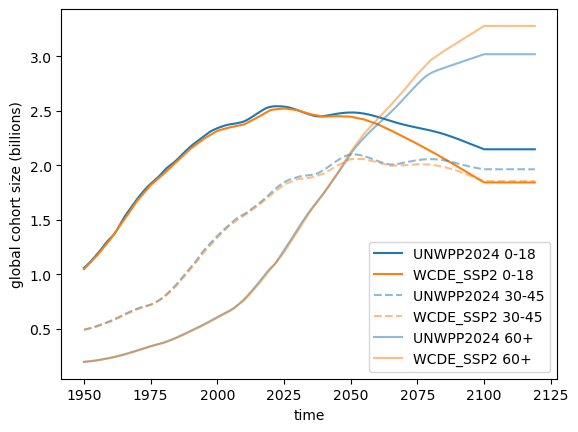

In [38]:
fig,ax = plt.subplots()

factor = 1e6 

(da_cohort_size_unwpp / factor).sum(dim='country').sel(ages=slice(0,18)).sum(dim='ages').astype(float).plot(ax=ax, label='UNWPP2024 0-18')
(da_cohort_size_wcde / factor).sum(dim='country').sel(ages=slice(0,18)).sum(dim='ages').astype(float).plot(ax=ax, label='WCDE_SSP2 0-18')

(da_cohort_size_unwpp / factor).sum(dim='country').sel(ages=slice(30,45)).sum(dim='ages').astype(float).plot(ax=ax, label='UNWPP2024 30-45', c='C0',ls='--',alpha=.5)
(da_cohort_size_wcde / factor).sum(dim='country').sel(ages=slice(30,45)).sum(dim='ages').astype(float).plot(ax=ax, label='WCDE_SSP2 30-45',c='C1',ls='--',alpha=.5)

(da_cohort_size_unwpp / factor).sum(dim='country').sel(ages=slice(60,101)).sum(dim='ages').astype(float).plot(ax=ax, label='UNWPP2024 60+', c='C0',alpha=.5)
(da_cohort_size_wcde / factor).sum(dim='country').sel(ages=slice(60,101)).sum(dim='ages').astype(float).plot(ax=ax, label='WCDE_SSP2 60+',c='C1',alpha=.5)


plt.legend()
plt.ylabel('global cohort size (billions)')

# SSP2 seems to be slightly older globally, compared to UNWPP2024

#### compare country masks fractional v. shapefile, at 0.1 v. 0.5 resolution 

In [ ]:
# da_countrymasks = load_countrymasks_fillcoasts(
#                             filepath_countrymask,
#                             preprocess=False, # True if you want to preprocess
#                             fillcoast=False, # fill coastal pixels to not lose coastal pops (done in preprocessed files)
#                             fix_smallislands=False, # done in preprocessed input files for 0.5, not for 0.1 - TODO: check if necessary at 0.1 or not ! 
#                             bbox=bbox_europe,
#                             )
# these are already preprocessed (cleaned country names and coastal pixels are filled to sum to 1 to not lose population)



In [39]:
da_population

# population data extended constant past 2100

<xarray.DataArray 'total-population' (time: 170, lat: 360, lon: 720)>
dask.array<getitem, shape=(170, 360, 720), dtype=float32, chunksize=(20, 360, 720), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
Attributes:
    long_name:  Population_count
    units:      1

In [40]:
df_life_expectancy_5

# life expectancy at age 5 (corrected to be at birth and period) for each country/birth year - last estimate data is for 2018 birth year, thereafter they are projections - all available from UNWPP2024



Country,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela (Bolivarian Republic of),Viet Nam,Wallis and Futuna Islands,Western Sahara,Yemen,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
1950,54.7051,72.2933,60.0833,73.0935,78.4736,60.3326,71.0196,72.9259,73.986,73.5868,...,76.9994,71.5994,62.5983,68.7405,68.7827,60.0066,58.8167,63.0338,68.3711,67.5054
1951,54.9914,73.117,59.9968,73.3142,78.7848,60.4601,71.3453,73.1271,74.8442,73.7835,...,77.1543,71.7428,63.0074,69.2576,69.2194,60.2678,59.0545,63.2106,68.5591,67.7423
1952,55.3287,74.0791,59.8907,73.5873,79.0685,60.5222,71.6498,73.3441,74.3825,73.9763,...,77.303,71.891,63.3789,69.761,69.5801,60.5338,59.2911,63.3482,68.714,67.9825
1953,55.6465,75.0774,59.7686,74.0095,79.449,60.5925,71.9511,73.5912,75.4063,74.1662,...,77.4524,72.0515,63.7587,70.2772,69.953,60.8083,59.5263,63.5801,68.9539,68.2102
1954,55.9651,75.9208,59.6571,74.5568,79.7661,60.6646,72.3025,73.8626,75.209,74.3545,...,77.5948,72.2161,64.1316,70.8107,70.2969,61.0874,59.7591,63.7344,69.1736,68.4717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,76.3344,86.7605,84.3678,79.983,90.9386,75.3352,86.2771,84.7939,84.5935,82.9247,...,85.1394,79.8067,79.167,80.2522,82.4702,86.024,79.8237,78.3779,76.2603,72.3912
2022,76.441,86.923,84.5161,80.1066,91.0655,75.4478,86.4557,84.9577,84.7182,83.0688,...,85.2944,79.9032,79.3171,80.3761,82.5996,86.1649,79.9495,78.4595,76.3663,72.6039
2023,76.5566,87.0848,84.6631,80.2251,91.1889,75.5534,86.6262,85.1138,84.8523,83.2152,...,85.4518,80.0172,79.4741,80.4974,82.723,86.2609,80.0731,78.5283,76.4686,72.8116


In [41]:
da_countrymasks

# with bounding box pre-selects countries

<xarray.DataArray (lat: 360, lon: 720, country: 225)>
dask.array<getitem, shape=(360, 720, 225), dtype=float32, chunksize=(299, 604, 185), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * country  (country) object 'AFG' 'AGO' 'ALB' 'AND' ... 'ZAF' 'ZMB' 'ZWE'

#### b) from wrapper function (filtered country list)

Wrapper function runs all functions and then filters object based on data available in all datasets, and optionally in World Bank regions / income level categorization, so that all the objects are coherent

Global, matching on data availability = 198 countries

Global, matching based on data availability and world bank inclusion = 185 countries


In [42]:
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] # NOTE: not a gdf anymore! its now da_countrymasks
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
#df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
#countries_regions, countries_mask = d_countries['mask'] # NA 

In [43]:
df_countries

,abbreviation,region,incomegroup,country_code,SSP name,name
name,,,,,,
Afghanistan,AFG,South Asia,Low income,3,Afghanistan,Afghanistan
Albania,ALB,Europe & Central Asia,Upper middle income,103,Albania,Albania
Algeria,DZA,Middle East & North Africa,Upper middle income,203,Algeria,Algeria
Andorra,AND,Europe & Central Asia,High income,403,Andorra,Andorra
Angola,AGO,Sub-Saharan Africa,Lower middle income,503,Angola,Angola
...,...,...,...,...,...,...
Venezuela (Bolivarian Republic of),VEN,Latin America & Caribbean,NaN,22503,Venezuela,Venezuela (Bolivarian Republic of)
Viet Nam,VNM,East Asia & Pacific,Lower middle income,22603,Viet Nam,Viet Nam
Yemen,YEM,Middle East & North Africa,Low income,23003,Yemen,Yemen


In [44]:
gdf_country_borders

<xarray.DataArray (lat: 360, lon: 720, country: 192)>
dask.array<getitem, shape=(360, 720, 192), dtype=float32, chunksize=(299, 604, 157), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * country  (country) object 'AFG' 'AGO' 'ALB' 'AND' ... 'ZAF' 'ZMB' 'ZWE'

In [45]:
da_regions

array(['South Asia', 'Europe & Central Asia',
       'Middle East & North Africa', 'Sub-Saharan Africa',
       'Latin America & Caribbean', 'East Asia & Pacific',
       'North America'], dtype=object)

In [46]:
da_population

<xarray.DataArray 'total-population' (time: 170, lat: 360, lon: 720)>
dask.array<getitem, shape=(170, 360, 720), dtype=float32, chunksize=(20, 360, 720), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
Attributes:
    long_name:  Population_count
    units:      1

In [47]:
df_life_expectancy_5

Country,Afghanistan,Albania,Algeria,Andorra,Angola,Antigua and Barbuda,Argentina,Armenia,Australia,Austria,...,United Kingdom,United States of America,Uruguay,Uzbekistan,Vanuatu,Venezuela (Bolivarian Republic of),Viet Nam,Yemen,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
1950,54.7051,72.2933,60.0833,78.4736,60.3326,72.9259,73.986,73.5868,78.1507,77.328,...,78.2731,77.8523,76.9994,71.5994,62.5983,68.7405,68.7827,63.0338,68.3711,67.5054
1951,54.9914,73.117,59.9968,78.7848,60.4601,73.1271,74.8442,73.7835,77.9627,77.2763,...,78.4502,77.9013,77.1543,71.7428,63.0074,69.2576,69.2194,63.2106,68.5591,67.7423
1952,55.3287,74.0791,59.8907,79.0685,60.5222,73.3441,74.3825,73.9763,78.2529,77.0455,...,78.5535,77.6759,77.303,71.891,63.3789,69.761,69.5801,63.3482,68.714,67.9825
1953,55.6465,75.0774,59.7686,79.449,60.5925,73.5912,75.4063,74.1662,78.6761,77.7793,...,78.6526,77.9369,77.4524,72.0515,63.7587,70.2772,69.953,63.5801,68.9539,68.2102
1954,55.9651,75.9208,59.6571,79.7661,60.6646,73.8626,75.209,74.3545,78.3229,77.7012,...,78.7528,78.115,77.5948,72.2161,64.1316,70.8107,70.2969,63.7344,69.1736,68.4717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,76.3344,86.7605,84.3678,90.9386,75.3352,84.7939,84.5935,82.9247,90.5951,88.7147,...,88.0767,86.2015,85.1394,79.8067,79.167,80.2522,82.4702,78.3779,76.2603,72.3912
2022,76.441,86.923,84.5161,91.0655,75.4478,84.9577,84.7182,83.0688,90.729,88.8823,...,88.2177,86.3436,85.2944,79.9032,79.3171,80.3761,82.5996,78.4595,76.3663,72.6039
2023,76.5566,87.0848,84.6631,91.1889,75.5534,85.1138,84.8523,83.2152,90.8624,89.044,...,88.3511,86.4758,85.4518,80.0172,79.4741,80.4974,82.723,78.5283,76.4686,72.8116


In [48]:
da_cohort_size

<xarray.DataArray 'cohort_size' (country: 192, time: 170, ages: 101)>
array([[[3.1581850e+02, 2.6917450e+02, 2.5050700e+02, ...,
         1.5000000e-03, 5.0000000e-04, 0.0000000e+00],
        [3.1596150e+02, 2.6723850e+02, 2.5043500e+02, ...,
         1.0000000e-03, 5.0000000e-04, 0.0000000e+00],
        [3.2254100e+02, 2.6814350e+02, 2.4889100e+02, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        ...,
        [1.8011550e+03, 1.8048325e+03, 1.8074890e+03, ...,
         7.1515000e+00, 4.4495000e+00, 6.1445000e+00],
        [1.8011550e+03, 1.8048325e+03, 1.8074890e+03, ...,
         7.1515000e+00, 4.4495000e+00, 6.1445000e+00],
        [1.8011550e+03, 1.8048325e+03, 1.8074890e+03, ...,
         7.1515000e+00, 4.4495000e+00, 6.1445000e+00]],

       [[4.4996000e+01, 3.9432000e+01, 3.5923000e+01, ...,
         1.6000000e-02, 1.0500000e-02, 1.3500000e-02],
        [4.7037000e+01, 4.0547500e+01, 3.7188500e+01, ...,
         1.4000000e-02, 9.0000000e-03, 1.1500000e-02],
        [4.9370500e+01, 4.2429500e+01, 3.8437000e+01, ...,
         1.2500000e-02, 8.0000000e-03, 1.2000000e-02],
...
        [9.1798000e+02, 9.1783250e+02, 9.1942400e+02, ...,
         5.3015000e+00, 3.4925000e+00, 5.7090000e+00],
        [9.1798000e+02, 9.1783250e+02, 9.1942400e+02, ...,
         5.3015000e+00, 3.4925000e+00, 5.7090000e+00],
        [9.1798000e+02, 9.1783250e+02, 9.1942400e+02, ...,
         5.3015000e+00, 3.4925000e+00, 5.7090000e+00]],

       [[1.2761300e+02, 1.0412350e+02, 8.7942000e+01, ...,
         7.5000000e-03, 4.5000000e-03, 5.0000000e-03],
        [1.3197050e+02, 1.2077800e+02, 1.0069000e+02, ...,
         7.5000000e-03, 5.0000000e-03, 6.0000000e-03],
        [1.3534650e+02, 1.2503900e+02, 1.1691000e+02, ...,
         5.5000000e-03, 5.5000000e-03, 5.5000000e-03],
        ...,
        [4.9595450e+02, 4.9633050e+02, 4.9703450e+02, ...,
         5.0470000e+00, 3.3800000e+00, 5.4865000e+00],
        [4.9595450e+02, 4.9633050e+02, 4.9703450e+02, ...,
         5.0470000e+00, 3.3800000e+00, 5.4865000e+00],
        [4.9595450e+02, 4.9633050e+02, 4.9703450e+02, ...,
         5.0470000e+00, 3.3800000e+00, 5.4865000e+00]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 9 ... 91 92 93 94 95 96 97 98 99 100

### c) Testing wrapper function with a bounding box (Europe)

In [49]:
flags

{'version': 2,
 'pop_resolution': 0.5,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024'}

In [50]:
bbox_europe = [ 31.99,  71.09, -14.96,  34.94]

In [51]:

d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    ssp=2,
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = bbox_europe,

    filepath_countrymask = filepath_countrymask,    # country masks 
    preprocess=False,                               # NOTE preprocessing is already done in standard input files - TODO: add option to select shapefile or country mask
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )

loading cohort sizes from UNWPP2024
opening compass - historical
opening compass - ssp2


In [52]:
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] # NOTE: not a gdf anymore! (da_countrymasks)
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
#df_birthyears = d_countries['birth_years']
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
#countries_regions, countries_mask = d_countries['mask']

In [53]:
gdf_country_borders

<xarray.DataArray (lat: 78, lon: 100, country: 48)>
dask.array<getitem, shape=(78, 100, 48), dtype=float32, chunksize=(78, 100, 42), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 -14.75 -14.25 -13.75 -13.25 ... 33.75 34.25 34.75
  * lat      (lat) float64 70.75 70.25 69.75 69.25 ... 33.75 33.25 32.75 32.25
  * country  (country) object 'ALB' 'AND' 'AUT' 'BEL' ... 'TUN' 'TUR' 'UKR'

In [54]:
df_life_expectancy_5

Country,Albania,Algeria,Andorra,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Cyprus,...,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Tunisia,Türkiye,Ukraine,United Kingdom
Year,,,,,,,,,,,,,,,,,,,,,
1950,72.2933,60.0833,78.4736,77.328,75.3355,77.8648,70.1355,78.4307,76.3165,72.2451,...,74.7094,77.6059,76.3769,77.7527,80.1749,78.3759,62.9397,74.215,76.4168,78.2731
1951,73.117,59.9968,78.7848,77.2763,75.7719,78.0135,70.4649,77.6914,76.5287,72.5645,...,75.0297,77.7876,76.4921,77.2738,80.219,78.4089,63.4908,74.3061,76.7791,78.4502
1952,74.0791,59.8907,79.0685,77.0455,76.1716,78.1412,71.15,78.6301,76.8597,72.8389,...,75.8287,77.2865,76.5532,77.2174,80.0601,78.6051,64.2125,73.4723,77.1535,78.5535
1953,75.0774,59.7686,79.449,77.7793,76.8768,78.4919,71.7558,79.5434,77.093,73.1858,...,76.5709,78.4581,76.8142,78.9503,80.5827,79.2188,64.7408,72.9428,77.3328,78.6526
1954,75.9208,59.6571,79.7661,77.7012,77.8036,78.8723,72.8119,77.5044,77.2357,73.5729,...,77.1057,77.8273,77.0635,78.8173,80.8428,79.4077,65.2574,73.5414,77.8302,78.7528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,86.7605,84.3678,90.9386,88.7147,81.1799,88.8552,84.8188,82.5465,85.3918,88.3808,...,83.6672,85.1695,88.2295,90.3076,89.9191,90.6576,83.9189,85.1218,81.44,88.0767
2022,86.923,84.5161,91.0655,88.8823,81.3517,88.9993,84.9906,82.6858,85.5442,88.5442,...,83.8383,85.3294,88.3943,90.4504,90.0557,90.7919,84.0811,85.2946,81.5875,88.2177
2023,87.0848,84.6631,91.1889,89.044,81.5236,89.1554,85.1543,82.8324,85.7104,88.712,...,84.0101,85.4824,88.5423,90.5779,90.1884,90.9169,84.2544,85.4623,81.7357,88.3511


In [55]:
da_cohort_size

<xarray.DataArray 'cohort_size' (country: 48, time: 170, ages: 101)>
array([[[4.499600e+01, 3.943200e+01, 3.592300e+01, ..., 1.600000e-02,
         1.050000e-02, 1.350000e-02],
        [4.703700e+01, 4.054750e+01, 3.718850e+01, ..., 1.400000e-02,
         9.000000e-03, 1.150000e-02],
        [4.937050e+01, 4.242950e+01, 3.843700e+01, ..., 1.250000e-02,
         8.000000e-03, 1.200000e-02],
        ...,
        [7.185000e+00, 7.273000e+00, 7.355000e+00, ..., 4.602000e+00,
         3.962000e+00, 1.164450e+01],
        [7.185000e+00, 7.273000e+00, 7.355000e+00, ..., 4.602000e+00,
         3.962000e+00, 1.164450e+01],
        [7.185000e+00, 7.273000e+00, 7.355000e+00, ..., 4.602000e+00,
         3.962000e+00, 1.164450e+01]],

       [[3.731525e+02, 3.055335e+02, 2.777300e+02, ..., 2.410000e-01,
         1.530000e-01, 2.460000e-01],
        [4.070505e+02, 3.428770e+02, 2.932695e+02, ..., 2.100000e-01,
         1.455000e-01, 2.265000e-01],
        [4.159950e+02, 3.744005e+02, 3.293815e+02, ..., 1.520000e-01,
         1.270000e-01, 2.135000e-01],
...
        [7.932850e+01, 7.982500e+01, 8.038500e+01, ..., 4.846700e+01,
         3.912200e+01, 1.296195e+02],
        [7.932850e+01, 7.982500e+01, 8.038500e+01, ..., 4.846700e+01,
         3.912200e+01, 1.296195e+02],
        [7.932850e+01, 7.982500e+01, 8.038500e+01, ..., 4.846700e+01,
         3.912200e+01, 1.296195e+02]],

       [[8.239080e+02, 8.580860e+02, 9.065185e+02, ..., 4.940000e-01,
         2.815000e-01, 3.145000e-01],
        [7.908355e+02, 8.074730e+02, 8.500425e+02, ..., 5.070000e-01,
         2.955000e-01, 3.375000e-01],
        [7.721995e+02, 7.733385e+02, 7.974905e+02, ..., 5.345000e-01,
         3.070000e-01, 3.605000e-01],
        ...,
        [6.375695e+02, 6.399760e+02, 6.425835e+02, ..., 1.218475e+02,
         8.942950e+01, 1.687090e+02],
        [6.375695e+02, 6.399760e+02, 6.425835e+02, ..., 1.218475e+02,
         8.942950e+01, 1.687090e+02],
        [6.375695e+02, 6.399760e+02, 6.425835e+02, ..., 1.218475e+02,
         8.942950e+01, 1.687090e+02]]])
Coordinates:
  * country  (country) object 'Albania' 'Algeria' ... 'Ukraine' 'United Kingdom'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 9 ... 91 92 93 94 95 96 97 98 99 100

In [56]:
da_regions

array(['Europe & Central Asia', 'Middle East & North Africa'],
      dtype=object)

In [57]:
da_population

<xarray.DataArray 'total-population' (time: 170, lat: 78, lon: 100)>
dask.array<getitem, shape=(170, 78, 100), dtype=float32, chunksize=(20, 78, 100), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * lon      (lon) float64 -14.75 -14.25 -13.75 -13.25 ... 33.75 34.25 34.75
  * lat      (lat) float64 70.75 70.25 69.75 69.25 ... 33.75 33.25 32.75 32.25
Attributes:
    long_name:  Population_count
    units:      1

## Part 2. Lifetime exposure

In [58]:
# GMT-mapping + lifetime exposure functions

# TODO 


